In [22]:
import json
import ast
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx

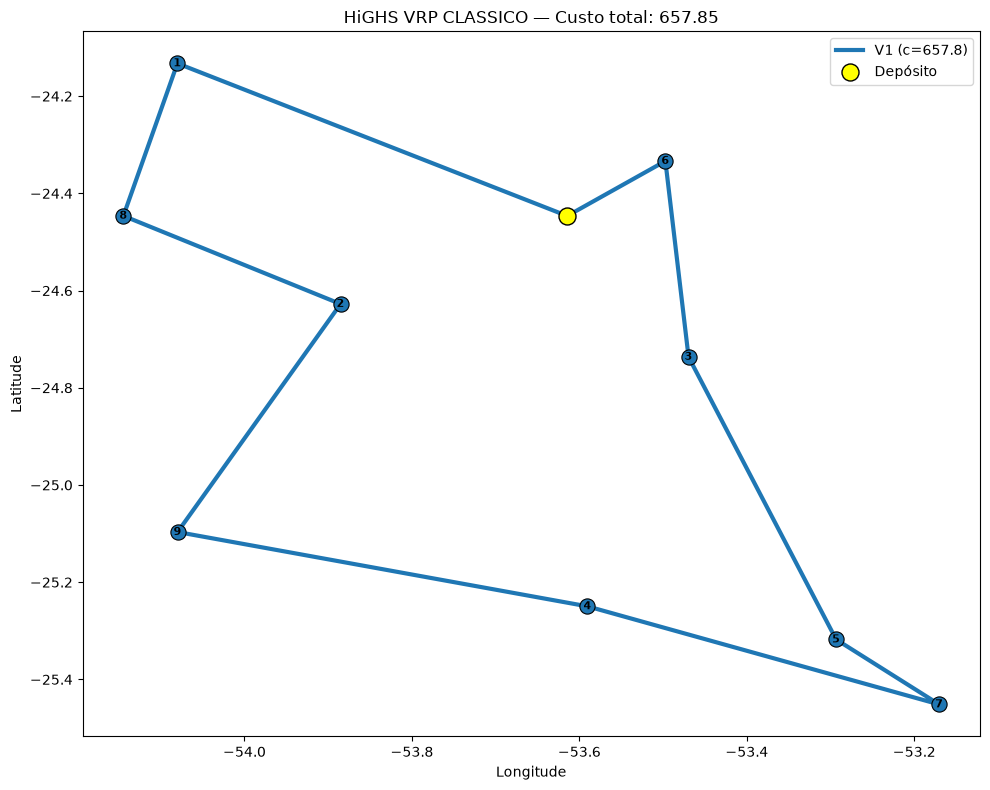

<Figure size 640x480 with 0 Axes>

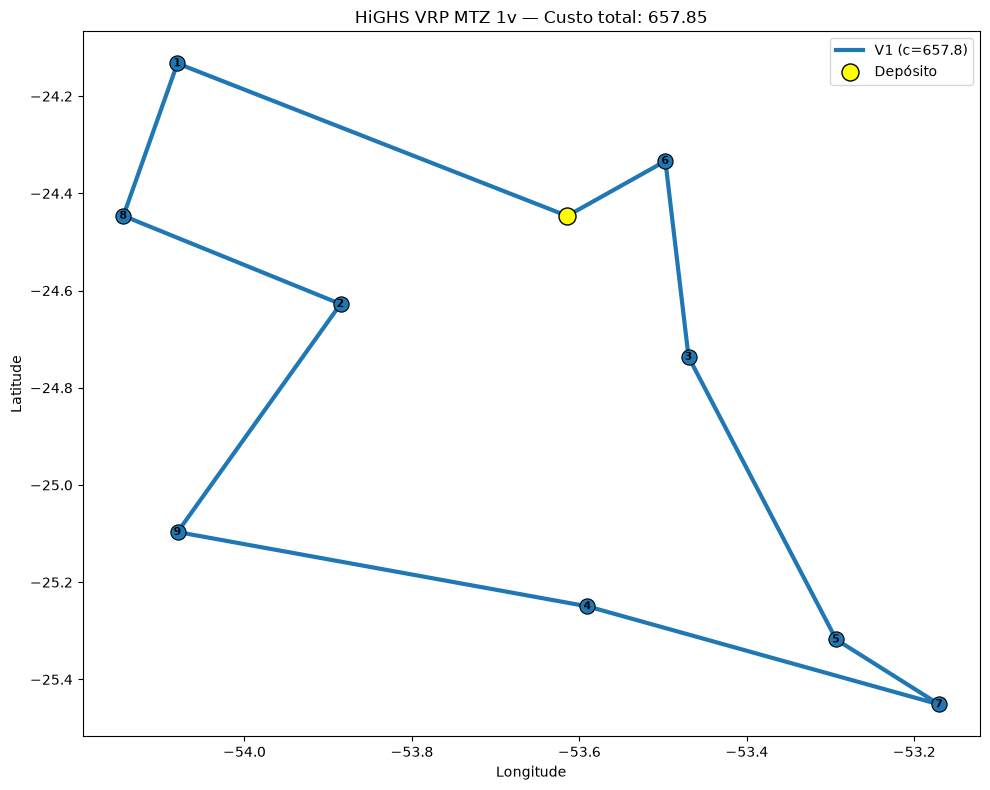

<Figure size 640x480 with 0 Axes>

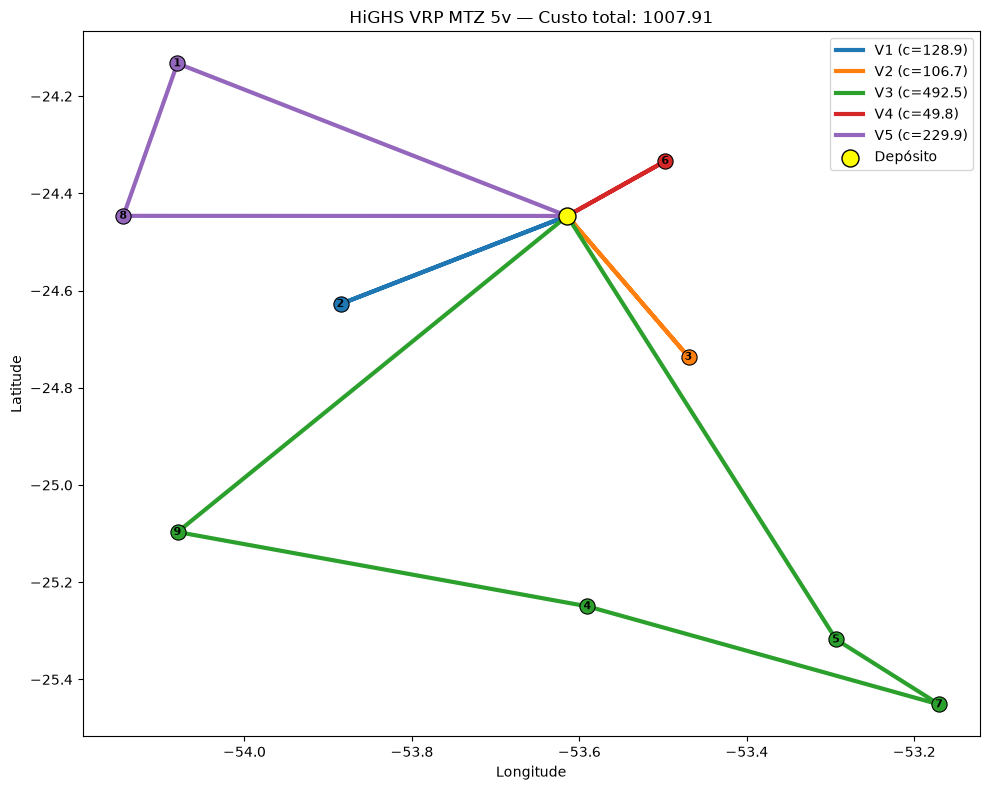

<Figure size 640x480 with 0 Axes>

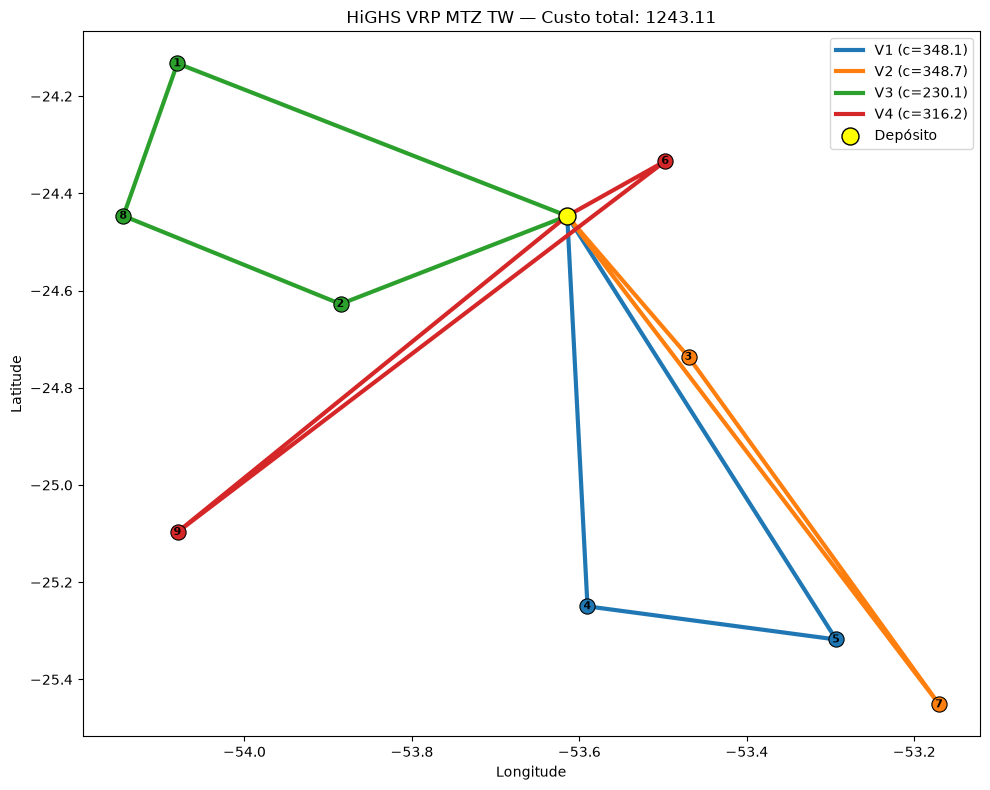

<Figure size 640x480 with 0 Axes>

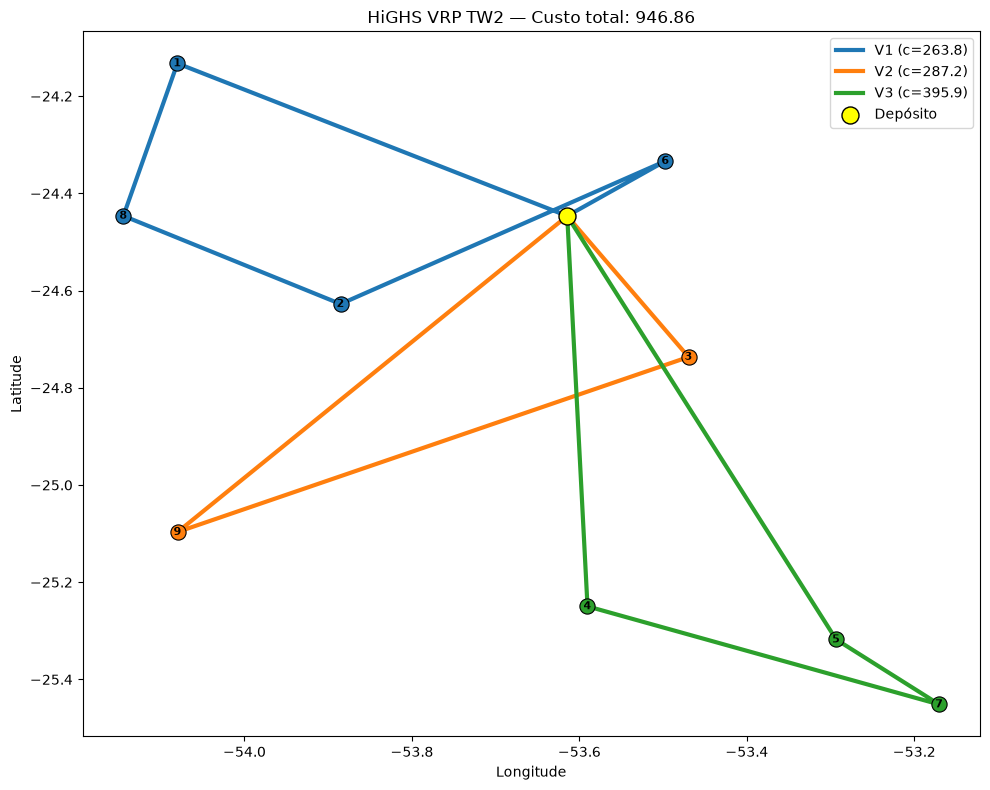

<Figure size 640x480 with 0 Axes>

In [23]:

default_zoom = 15

def plot_rota(row, nome_arq_save=None):
  with open(row["nomearq"], "r") as f:
    dados = json.load(f)

  pontos = dados["pontos"]
  lat = [float(p["latitude"]) for p in pontos]
  lon = [float(p["longitude"]) for p in pontos]

  subrotas = ast.literal_eval(row["custosub"])
  custos = ast.literal_eval(row["custocustosub"])

  fig, ax = plt.subplots(figsize=(10, 8))

  for k, rota in enumerate(subrotas):
    xs = [lon[i] for i in rota]
    ys = [lat[i] for i in rota]

    ax.plot(
      xs,
      ys,
      linewidth=3,
      color=plt.cm.tab10(k),
      label=f"V{k+1} (c={custos[k]:.1f})",
      zorder=3
    )

    ax.scatter(
      xs,
      ys,
      s=120,
      color=plt.cm.tab10(k),
      edgecolor="black",
      linewidth=0.8,
      zorder=5
    )

    for i in rota:
      ax.text(
        lon[i],
        lat[i],
        str(i),
        fontsize=8,
        ha="center",
        va="center",
        fontweight="bold",
        zorder=6
      )

  ax.scatter(
    lon[0],
    lat[0],
    s=150,
    color="yellow",
    edgecolor="black",
    zorder=7,
    label="Depósito"
  )

  #ctx.add_basemap(ax,crs="EPSG:4326",source=ctx.providers.Esri.WorldStreetMap, zoom=10)

  ax.set_xlabel("Longitude")
  ax.set_ylabel("Latitude")
  ax.set_title(f"{row['modelo']} — Custo total: {row['custototal']:.2f}")

  ax.legend()
  plt.tight_layout()
  plt.show()

  if nome_arq_save:
    plt.savefig("graficos/"+nome_arq_save, dpi=300, bbox_inches="tight")

df = pd.read_csv("resultados.csv")

for i in df.iterrows():
  plot_rota(i[1], nome_arq_save=f"rota_{i[1]['modelo']}.png")

